# GermEval 2026 — Baseline Results Summary

Summarizes and visualizes the TF-IDF + Logistic Regression baseline (`src/training/train_baseline.py`) across the four subtasks: `c2a`, `dbo`, `def`, `vio`.

Re-run `python -m src.training.train_baseline --task <task>` for any subtask, then re-run this notebook — every section below picks up whatever results exist in `results/tfidf_baseline/` and skips tasks that haven't been trained yet.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load import TASKS, load_split
from src.evaluation.explain import top_features

RESULTS_DIR = PROJECT_ROOT / "results" / "tfidf_baseline"
CONFIG = yaml.safe_load((PROJECT_ROOT / "configs" / "tfidf_baseline.yaml").read_text(encoding="utf-8"))

In [2]:
# Validated categorical palette (fixed hue order — never cycled/reassigned)
CATEGORICAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
POSITIVE, NEGATIVE, NEUTRAL = "#2a78d6", "#e34948", "#c3c2b7"  # diverging pair for +/- feature weights
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#1c5cab", "#104281"]  # sequential ramp for magnitude
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

BLUE_CMAP = LinearSegmentedColormap.from_list("blue_seq", SEQ_BLUE)
TASK_COLOR = dict(zip(TASKS, CATEGORICAL))

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "grid.color": GRID,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "font.size": 11,
})


def class_colors(labels):
    """Assign the fixed categorical palette to class labels, always mapping
    the negative/no-signal class ("nothing" or False) to neutral gray."""
    colors, palette_iter, assigned = {}, iter(CATEGORICAL), {}
    for label in labels:
        key = str(label).lower()
        if key not in assigned:
            assigned[key] = NEUTRAL if key in ("false", "nothing") else next(palette_iter)
        colors[label] = assigned[key]
    return colors

## 1. Label distribution per subtask

All four subtasks are heavily imbalanced — the harmful classes are rare. Counts are shown on a log scale (with exact values labeled) so the rare classes stay visible.

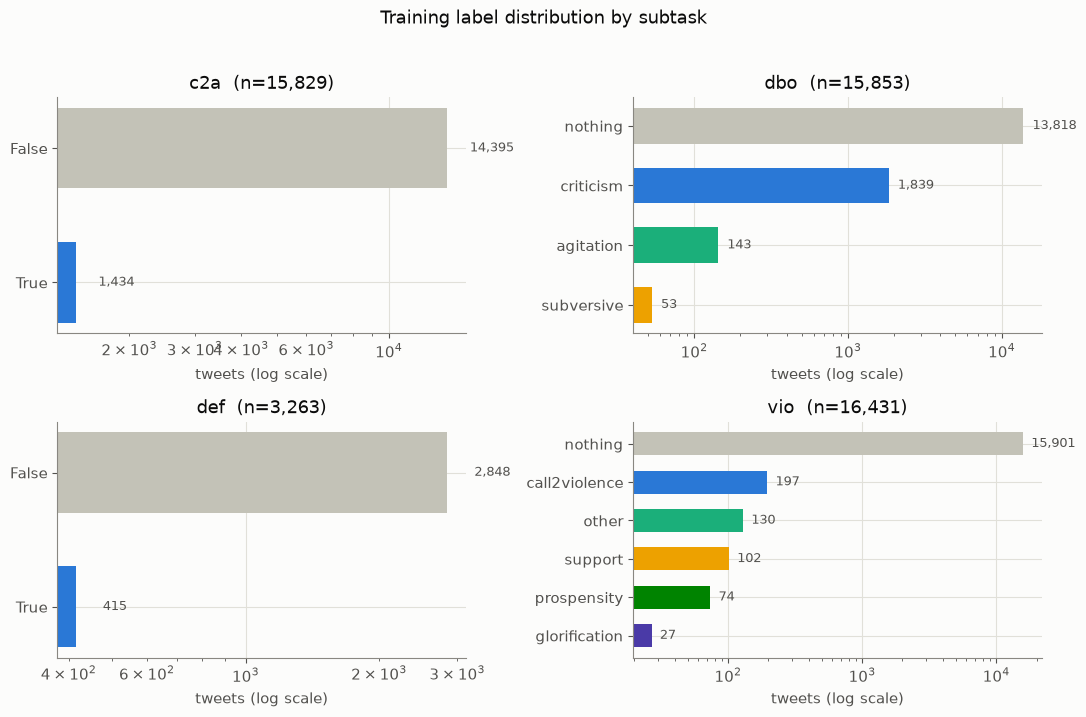

In [3]:
TASK_CLASS_COLORS = {}  # task -> {label: color}, reused in the explainability section

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, task in zip(axes.flat, TASKS):
    counts = load_split(task, "train")["label"].value_counts()
    colors_map = class_colors(counts.index)
    TASK_CLASS_COLORS[task] = colors_map

    ax.barh([str(l) for l in counts.index], counts.values, color=[colors_map[l] for l in counts.index], height=0.6)
    ax.set_xscale("log")
    ax.set_xlabel("tweets (log scale)")
    ax.set_title(f"{task}  (n={counts.sum():,})")
    ax.invert_yaxis()
    for y, v in enumerate(counts.values):
        ax.text(v * 1.15, y, f"{v:,}", va="center", fontsize=9, color=INK_SECONDARY)

fig.suptitle("Training label distribution by subtask", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 2. Baseline results

Metrics from `results/tfidf_baseline/<task>/metrics.json`, produced by `train_baseline.py` on a held-out validation split. Macro-averaged, since accuracy alone is misleading on imbalanced classes (predicting "nothing"/`FALSE` for everything already scores >85% accuracy on some tasks).

In [4]:
rows = []
for task in TASKS:
    metrics_path = RESULTS_DIR / task / "metrics.json"
    if metrics_path.exists():
        row = json.loads(metrics_path.read_text(encoding="utf-8"))
        row["task"] = task
        rows.append(row)
    else:
        print(f"[skip] {task}: no results yet — run `python -m src.training.train_baseline --task {task}`")

metrics_df = pd.DataFrame(rows).set_index("task")[["accuracy", "macro_precision", "macro_recall", "macro_f1"]] if rows else pd.DataFrame()
metrics_df.round(3)

,accuracy,macro_precision,macro_recall,macro_f1
task,,,,
c2a,0.881,0.678,0.761,0.708
dbo,0.836,0.493,0.449,0.439
def,0.865,0.697,0.702,0.699
vio,0.952,0.281,0.250,0.262


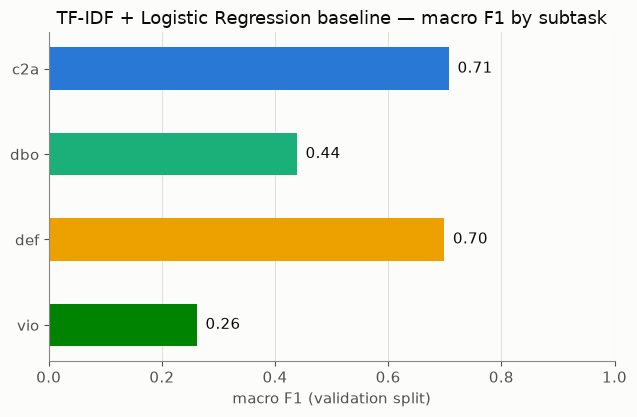

In [5]:
if not metrics_df.empty:
    fig, ax = plt.subplots(figsize=(6.5, 0.7 * len(metrics_df) + 1.5))
    tasks_present = metrics_df.index.tolist()
    bars = ax.barh(tasks_present, metrics_df["macro_f1"], color=[TASK_COLOR[t] for t in tasks_present], height=0.5)
    for bar, val in zip(bars, metrics_df["macro_f1"]):
        ax.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", color=INK)
    ax.set_xlim(0, 1)
    ax.set_xlabel("macro F1 (validation split)")
    ax.set_title("TF-IDF + Logistic Regression baseline — macro F1 by subtask")
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()

## 3. Confusion matrices

Re-creates each task's validation split with the same seed and split ratio used during training (see `configs/tfidf_baseline.yaml`), so the split is reproducible without needing to have saved it separately.

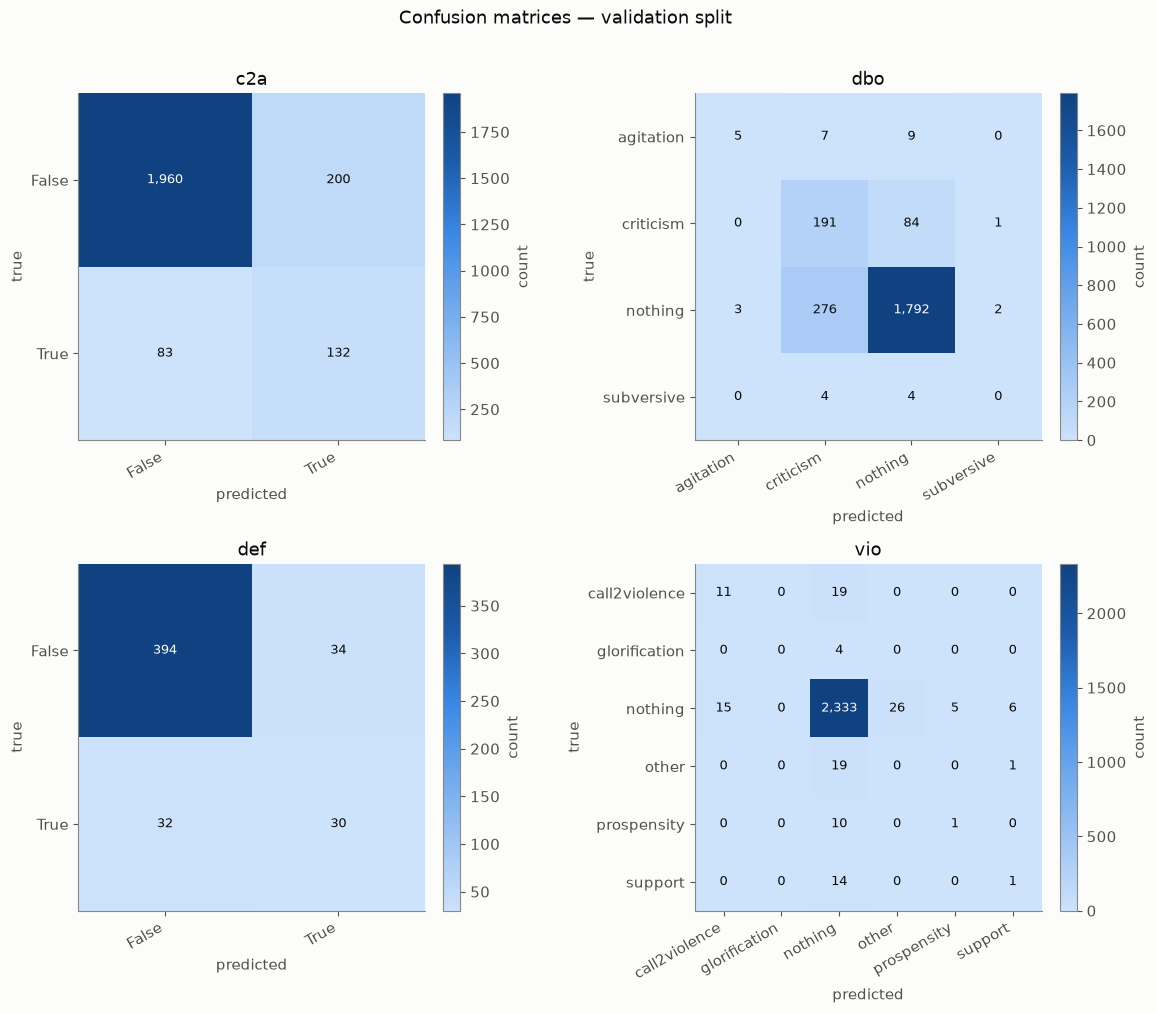

In [6]:
def plot_confusion_matrix(task, ax):
    model_path = RESULTS_DIR / task / "tfidf_baseline.joblib"
    if not model_path.exists():
        ax.axis("off")
        ax.set_title(f"{task}: no trained model yet", color=MUTED, fontsize=10)
        return

    pipeline = joblib.load(model_path)
    df = load_split(task, "train")
    _, X_val, _, y_val = train_test_split(
        df["text"], df["label"],
        test_size=CONFIG["data"]["val_size"], random_state=CONFIG["seed"], stratify=df["label"],
    )
    y_pred = pipeline.predict(X_val)
    labels = sorted(df["label"].unique(), key=str)
    cm = confusion_matrix(y_val, y_pred, labels=labels)
    labels_str = [str(l) for l in labels]

    im = ax.imshow(cm, cmap=BLUE_CMAP)
    ax.set_xticks(range(len(labels)), labels_str, rotation=30, ha="right")
    ax.set_yticks(range(len(labels)), labels_str)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(task)
    ax.grid(False)
    threshold = cm.max() / 2
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=9,
                     color=SURFACE if cm[i, j] > threshold else INK)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="count")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, task in zip(axes.flat, TASKS):
    plot_confusion_matrix(task, ax)
fig.suptitle("Confusion matrices — validation split", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

## 4. Explainability — top TF-IDF features per class

The whole point of the classic baseline over a black-box transformer: every prediction traces back to word weights you can read directly. For binary tasks, blue/red show which words push toward `TRUE` vs. `FALSE`. For multi-class tasks, each panel shows the words that most increase the odds of that specific class, colored to match the class in Section 1.

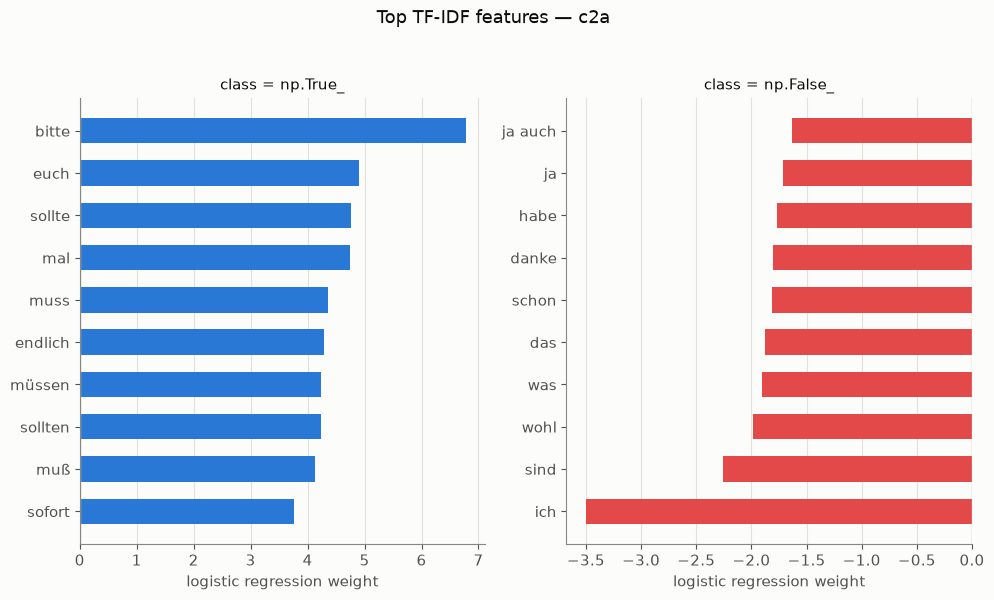

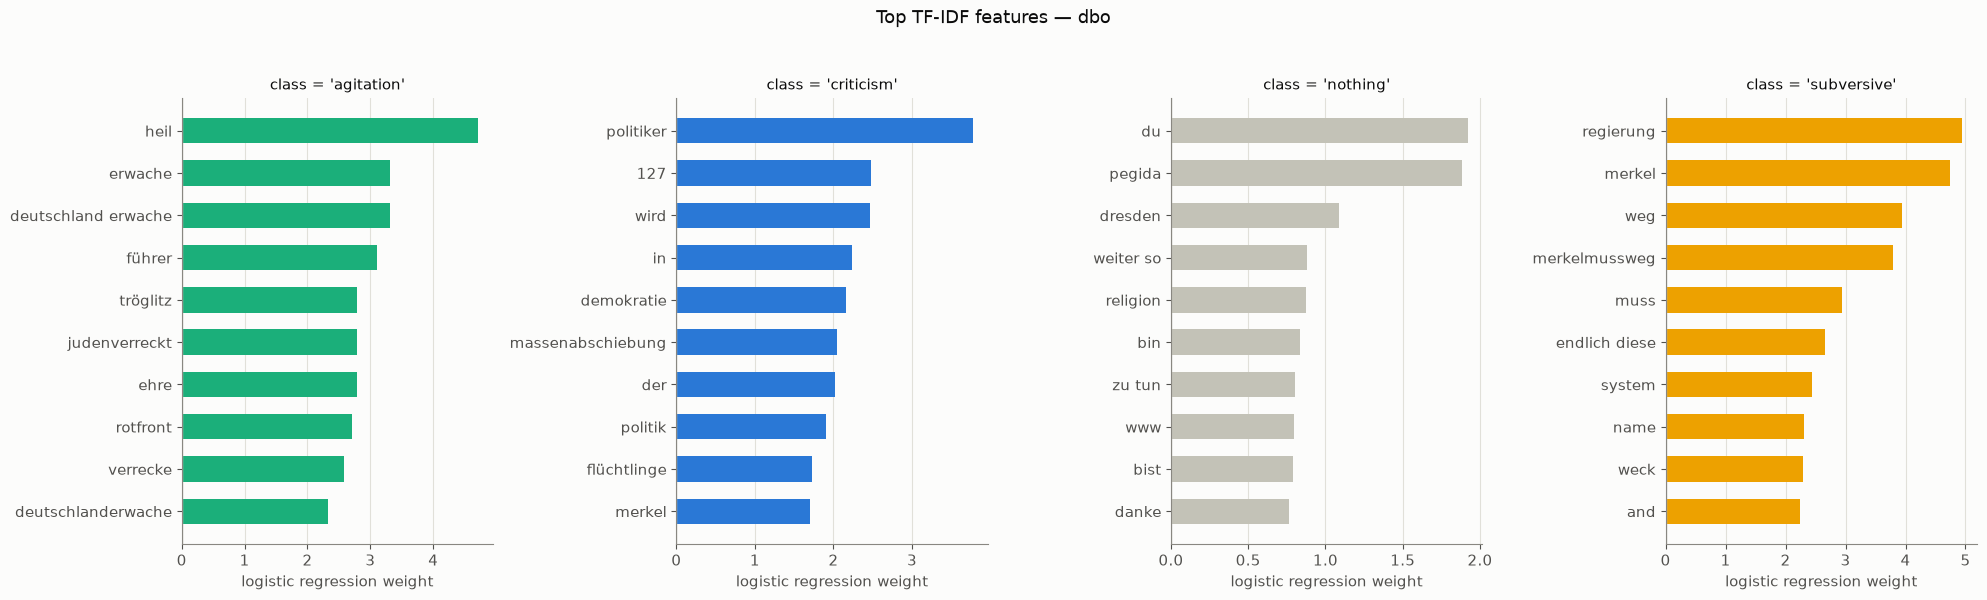

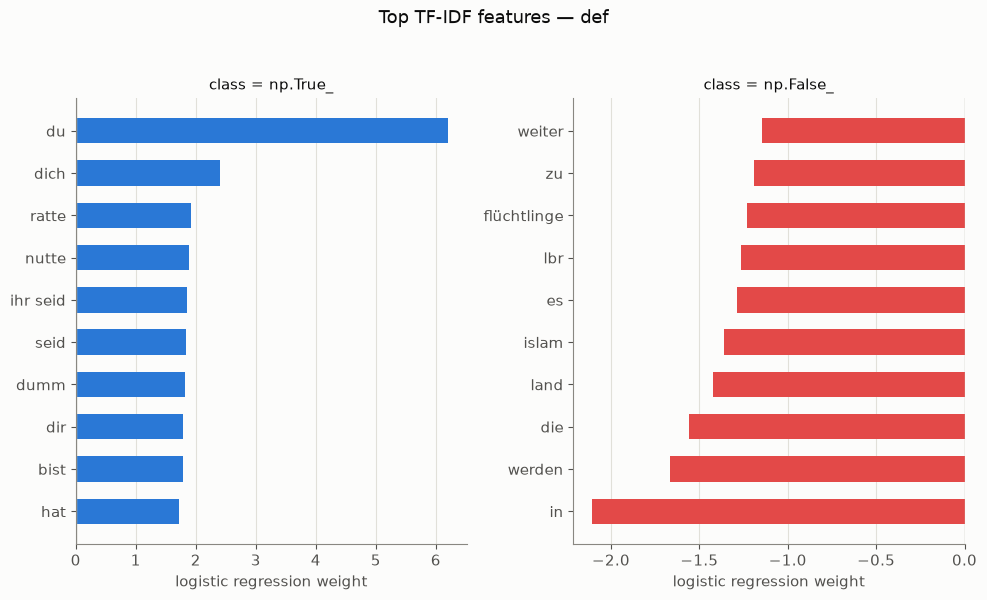

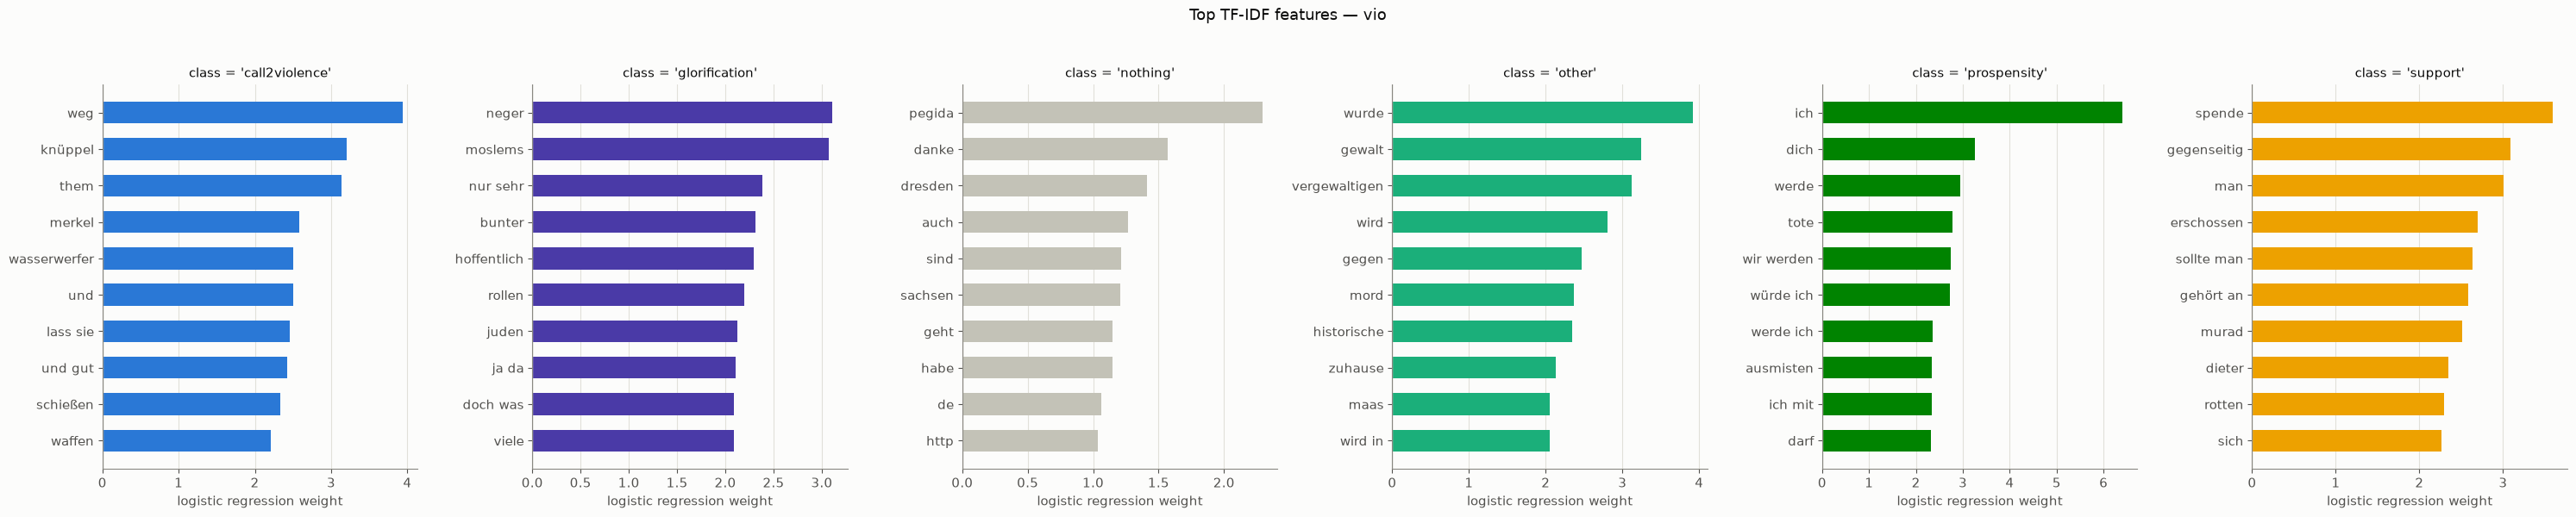

In [7]:
def plot_top_features(task, top_n=10):
    model_path = RESULTS_DIR / task / "tfidf_baseline.joblib"
    if not model_path.exists():
        print(f"[skip] {task}: no trained model yet")
        return

    pipeline = joblib.load(model_path)
    feats = top_features(pipeline.named_steps["tfidf"], pipeline.named_steps["clf"], top_n=top_n)
    classes = list(feats.keys())
    binary = len(classes) == 2
    class_colors_for_task = TASK_CLASS_COLORS.get(task, {})

    fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 0.4 * top_n + 1.8), squeeze=False)
    for ax, cls in zip(axes[0], classes):
        words, weights = zip(*feats[cls])
        order = np.argsort(weights)
        words = [words[i] for i in order]
        weights = [weights[i] for i in order]
        if binary:
            colors = [POSITIVE if w >= 0 else NEGATIVE for w in weights]
        else:
            colors = [class_colors_for_task.get(cls, CATEGORICAL[0])] * len(words)

        ax.barh(words, weights, color=colors, height=0.6)
        ax.axvline(0, color=NEUTRAL, linewidth=1)
        ax.set_title(f"class = {cls!r}", fontsize=11)
        ax.set_xlabel("logistic regression weight")
        ax.grid(axis="y", visible=False)

    fig.suptitle(f"Top TF-IDF features — {task}", y=1.03, fontsize=13)
    fig.tight_layout()
    plt.show()


for task in TASKS:
    plot_top_features(task)

## 5. TF-IDF vs. gbert-base

Both models are evaluated on the same validation split (same seed, same split ratio — see `configs/tfidf_baseline.yaml` and `configs/gbert.yaml`), so the macro-F1 numbers are directly comparable.

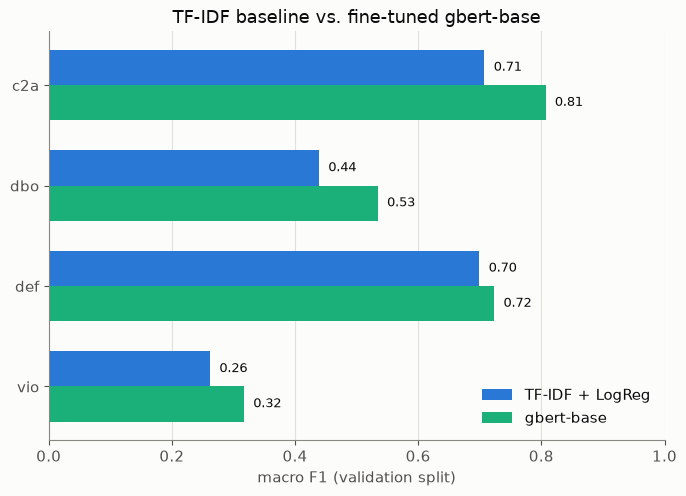

In [8]:
GBERT_RESULTS_DIR = PROJECT_ROOT / "results" / "gbert"
MODEL_COLOR = {"TF-IDF + LogReg": CATEGORICAL[0], "gbert-base": CATEGORICAL[1]}

rows = []
for task in TASKS:
    tfidf_path = RESULTS_DIR / task / "metrics.json"
    gbert_path = GBERT_RESULTS_DIR / task / "metrics.json"
    if tfidf_path.exists():
        rows.append({"task": task, "model": "TF-IDF + LogReg", **json.loads(tfidf_path.read_text(encoding="utf-8"))})
    if gbert_path.exists():
        rows.append({"task": task, "model": "gbert-base", **json.loads(gbert_path.read_text(encoding="utf-8"))})

compare_df = pd.DataFrame(rows)

if not compare_df.empty:
    tasks_present = [t for t in TASKS if t in compare_df["task"].values]
    models = ["TF-IDF + LogReg", "gbert-base"]
    bar_height = 0.35

    fig, ax = plt.subplots(figsize=(7, 0.9 * len(tasks_present) + 1.5))
    for i, model in enumerate(models):
        sub = compare_df[compare_df["model"] == model].set_index("task").reindex(tasks_present)
        y = np.arange(len(tasks_present)) + i * bar_height
        bars = ax.barh(y, sub["macro_f1"], height=bar_height, color=MODEL_COLOR[model], label=model)
        for bar, val in zip(bars, sub["macro_f1"]):
            if pd.notna(val):
                ax.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height() / 2, f"{val:.2f}",
                        va="center", fontsize=9, color=INK)

    ax.set_yticks(np.arange(len(tasks_present)) + bar_height / 2, tasks_present)
    ax.set_xlim(0, 1)
    ax.set_xlabel("macro F1 (validation split)")
    ax.set_title("TF-IDF baseline vs. fine-tuned gbert-base")
    ax.legend(loc="lower right", frameon=False)
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()
else:
    print("No results yet for either model.")

## 6. Cross-validation: is the win real?

A single 15%-validation split is noisy for classes with single-digit support (`subversive` has 8 validation examples in one split). This section uses stratified K-fold CV instead (`--cv N` on both training scripts) to get a mean ± std macro-F1 per task, and adds a class-weighted gbert-base variant (`--class-weights`) to test whether weighting the loss by inverse class frequency helps the multi-class tasks.

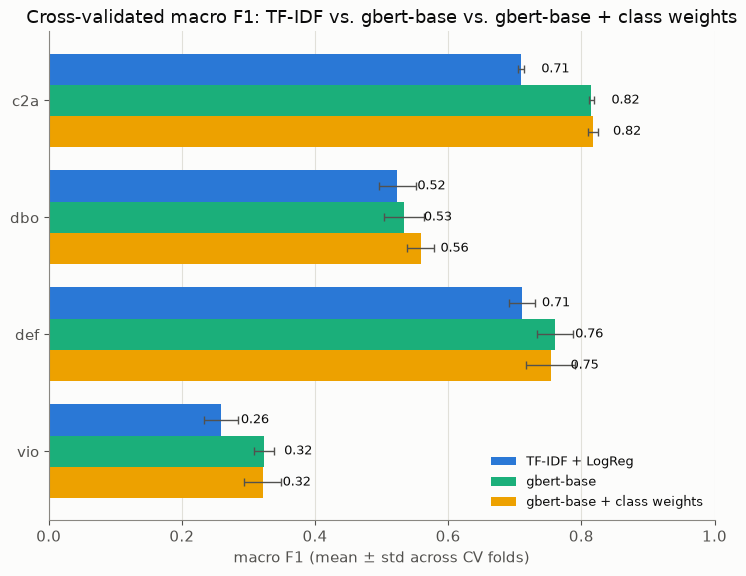

In [9]:
CV_MODEL_COLOR = {
    "TF-IDF + LogReg": CATEGORICAL[0],
    "gbert-base": CATEGORICAL[1],
    "gbert-base + class weights": CATEGORICAL[2],
}
CV_MODEL_DIR = {
    "TF-IDF + LogReg": RESULTS_DIR,
    "gbert-base": GBERT_RESULTS_DIR,
    "gbert-base + class weights": PROJECT_ROOT / "results" / "gbert_weighted",
}

rows = []
for model_name, base_dir in CV_MODEL_DIR.items():
    for task in TASKS:
        cv_path = base_dir / task / "cv_metrics.json"
        if cv_path.exists():
            cv = json.loads(cv_path.read_text(encoding="utf-8"))
            rows.append({"task": task, "model": model_name, "mean": cv["macro_f1_mean"], "std": cv["macro_f1_std"]})
        else:
            print(f"[skip] {model_name} / {task}: no cv_metrics.json yet")

cv_df = pd.DataFrame(rows)

if not cv_df.empty:
    tasks_present = [t for t in TASKS if t in cv_df["task"].values]
    models = list(CV_MODEL_DIR.keys())
    bar_height = 0.8 / len(models)

    fig, ax = plt.subplots(figsize=(7.5, 1.1 * len(tasks_present) + 1.5))
    for i, model in enumerate(models):
        sub = cv_df[cv_df["model"] == model].set_index("task").reindex(tasks_present)
        y = np.arange(len(tasks_present)) + i * bar_height
        bars = ax.barh(
            y, sub["mean"], height=bar_height, xerr=sub["std"], color=CV_MODEL_COLOR[model],
            label=model, capsize=3, error_kw={"ecolor": INK_SECONDARY, "linewidth": 1},
        )
        for bar, val in zip(bars, sub["mean"]):
            if pd.notna(val):
                ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2, f"{val:.2f}",
                        va="center", fontsize=9, color=INK)

    ax.set_yticks(np.arange(len(tasks_present)) + bar_height, tasks_present)
    ax.set_xlim(0, 1)
    ax.set_xlabel("macro F1 (mean ± std across CV folds)")
    ax.set_title("Cross-validated macro F1: TF-IDF vs. gbert-base vs. gbert-base + class weights")
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()
else:
    print("No CV results yet — run any training script with --cv N.")

## 7. Multi-task learning — a negative result

`c2a`/`dbo`/`vio` overlap 72-75% by tweet id (the same underlying tweet corpus, annotated for different phenomena), so a natural idea is one shared gbert-base encoder with a classification head per subtask, trained jointly on the pooled corpus (`src/training/train_multitask.py`), hoping shared representations transfer useful signal between related tasks. It didn't help — every task did worse than its single-task counterpart. Kept here as a documented negative result rather than discarded, since understanding *why* an idea doesn't pan out is as informative as a positive result.

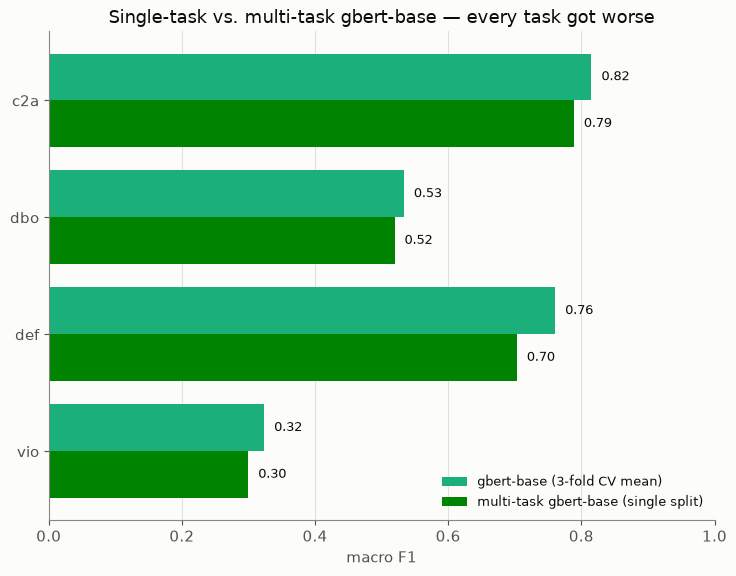

In [10]:
MULTITASK_DIR = PROJECT_ROOT / "results" / "multitask"

mt_rows = []
for task in TASKS:
    gbert_cv_path = GBERT_RESULTS_DIR / task / "cv_metrics.json"
    mt_path = MULTITASK_DIR / task / "metrics.json"
    if gbert_cv_path.exists() and mt_path.exists():
        gbert_cv = json.loads(gbert_cv_path.read_text(encoding="utf-8"))
        mt = json.loads(mt_path.read_text(encoding="utf-8"))
        mt_rows.append({
            "task": task,
            "gbert-base (3-fold CV mean)": gbert_cv["macro_f1_mean"],
            "multi-task gbert-base (single split)": mt["macro_f1"],
        })
    else:
        print(f"[skip] {task}: missing gbert CV or multitask results")

mt_df = pd.DataFrame(mt_rows).set_index("task") if mt_rows else pd.DataFrame()

if not mt_df.empty:
    tasks_present = [t for t in TASKS if t in mt_df.index]
    models = mt_df.columns.tolist()
    colors = [CATEGORICAL[1], CATEGORICAL[3]]
    bar_height = 0.8 / len(models)

    fig, ax = plt.subplots(figsize=(7.5, 1.1 * len(tasks_present) + 1.5))
    for i, (model, color) in enumerate(zip(models, colors)):
        y = np.arange(len(tasks_present)) + i * bar_height
        vals = mt_df.loc[tasks_present, model]
        bars = ax.barh(y, vals, height=bar_height, color=color, label=model)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height() / 2, f"{val:.2f}",
                    va="center", fontsize=9, color=INK)

    ax.set_yticks(np.arange(len(tasks_present)) + bar_height / 2, tasks_present)
    ax.set_xlim(0, 1)
    ax.set_xlabel("macro F1")
    ax.set_title("Single-task vs. multi-task gbert-base — every task got worse")
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    ax.grid(axis="y", visible=False)
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()
else:
    print("No multi-task results yet — run train_multitask.py.")

## 8. Takeaways

- All four subtasks are severely imbalanced, so macro-F1 (not accuracy) is the metric that matters here.
- A simple, fully transparent TF-IDF + Logistic Regression model already picks up intuitive signal (e.g. imperative/modal words for `c2a`'s calls to action) — kept as the interpretable reference point throughout.
- gbert-base beats TF-IDF on every subtask, but cross-validation matters: the single-split comparison made `dbo` look like a clean +0.10 transformer win; averaged over folds the real gap is much smaller (0.524 vs. 0.533) — that split was an unlucky draw for TF-IDF, not a reliable model difference.
- Class weighting only clearly helps on `dbo` (better mean *and* lower variance). On `c2a`/`def`/`vio` it's a wash or slightly worse, and it increases variance on `vio`. Our read: weighting helps a rare-but-learnable class (`dbo`'s `criticism`/`agitation`, hundreds/dozens of examples), but can't manufacture signal for classes with only a handful of examples (`vio`'s `glorification`, 27 examples) — that's a data-scarcity ceiling, not something the loss function can fix.
- Multi-task learning across the four related subtasks made every single one worse, most likely because each task's head sees a smaller effective slice of its own labeled data per epoch when training is spread across the pooled corpus, compounded by naive unweighted loss summing. A documented negative result, not pursued further — the deployable models stay single-task.
- Fill in this notebook's blanks by running `train_baseline.py` / `train_transformer.py` (with `--cv N` and/or `--class-weights`) for any missing task/variant; every cell above re-renders automatically from whatever's in `results/`.